# Brain-TokenGT — competitor baseline on DELCODE (MCI vs. converter)

Runs **Brain-TokenGT** (Dong et al., *Beyond the Snapshot*, MICCAI 2023) through the
*same protocol* as the CLASSIFIER longitudinal models, so the two are directly
comparable.

**What is being run.** `BRAINTOKENGT/model/` is a port of the authors' released
implementation (kept pristine at `Brain-TokenGT/`). The port generalises the
hardcoded `(M=90, T=3)` shapes and removes hardcoded CUDA placement; it changes no
arithmetic. `BRAINTOKENGT/tests/test_upstream_equivalence.py` asserts the port
reproduces upstream bit-for-bit at the authors' published configuration.

**What is NOT the authors' code.** The training/evaluation harness. Upstream's
`main_optuna.py` trains on a single subject with no test split, so a harness had to
be written; it is the *same* `CLASSIFIER.common` machinery GELSTM runs through
(`run_kfold_cv`, `select_oof_threshold`, `save_run`), which is what makes the
comparison fair by construction.

Pipeline: `set_seed` → load splits → `prepare_data` (HOOK) → `build_model` (HOOK) →
`run_kfold_cv` (drives `train_fold` HOOK) → `select_oof_threshold` → `save_run` →
test (`eval_split` HOOK) → ROC → `early_detection_table` → `trajectory_frame`.

In [1]:
# === Papermill parameters (injected by run_experiment.py) ===
EXPERIMENT_ID = None
MODE = None
MODEL = None
ADAPTER = None
DATASET = None
SEED = 42
GAAE_CHECKPOINT_PATH = None   # accepted for schema parity; Brain-TokenGT is end-to-end
THRESHOLD_MODE = None         # None -> interactive prompt; else youden | best-f1 | fixed
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = None
RESOLVED_CONFIG = None        # merged hyperparameter dict (json < hyperparams)
RUN_DIR = None
RUN_NAME = None

In [2]:
# Parameters
EXPERIMENT_ID = "braintokengt-smoke"
MODE = "longitudinal"
MODEL = "BRAINTOKENGT"
DATASET = "DELCODE_WHOLE_BRAIN"
SEED = 42
GAAE_CHECKPOINT_PATH = None
THRESHOLD_MODE = "best-f1"
FIXED_THRESHOLD = None
WANDB_ENABLED = False
OUTPUT_DIR = "outputs/braintokengt-smoke"
RESOLVED_CONFIG = {"_comment": "SMOKE CONFIG \u2014 wiring check only, results are meaningless. 12 subjects, 3 folds, 3 epochs. Use before committing GPU time to the full cohort.", "in_features": 200, "num_nodes": 200, "output_sizes": [16, 16], "nhead": 2, "num_layers": 1, "static_edge_topk": 90, "edge_weight_mode": "binary", "readout": "mean", "force_single_head": True, "train_give": False, "edge_density": 0.15012345679012346, "adjacency_metric": "raw", "min_visits": 2, "max_visits": 3, "max_subjects": 12, "optimizer": "Adam", "learning_rate": 0.001, "weight_decay": 0.0, "epochs": 3, "early_stopping_patience": 3, "batch_size": 4, "use_class_cost_weights": True, "grad_clip": 1.0, "n_folds": 3}
RUN_DIR = "/mnt/e/fyassine/ad-early-detection/BRAINTOKENGT/outputs/braintokengt-smoke/runs/curious-dew-1-dbdbfab12-2026-08-15_01-15-42"
RUN_NAME = "curious-dew-1-dbdbfab12-2026-08-15_01-15-42"
ADAPTER = "braintokengt"


In [3]:
import sys
from pathlib import Path

repo_root    = Path('/mnt/e/fyassine/ad-early-detection')
package_root = repo_root / 'BRAINTOKENGT'
model_root   = repo_root / 'CLASSIFIER'
for _p in (str(repo_root), str(model_root)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print('repo_root:', repo_root)

repo_root: /mnt/e/fyassine/ad-early-detection


In [4]:
# Reproducibility seeding — must run before datasets, samplers, or models.
# NOTE: upstream's utils.set_seeds() seeds from int(time.time()) and is never called.
# We use the project's seeding helpers instead (.claude/rules/seeding.md).
from SHARED.seeding import set_seed, make_rng, make_torch_generator

set_seed(SEED)
rng       = make_rng(SEED)
torch_gen = make_torch_generator(SEED)
print(f'Seeded with SEED={SEED}')

Seeded with SEED=42


In [5]:
import json, os, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Shared, model-agnostic protocol machinery — the SAME objects the GELSTM
# experiments run through. Reused, never re-implemented (see adapter.py docstring).
from SHARED.sanity import run_full_audit
from SHARED.provenance import region_from_data_root
from SHARED import tracking
from CLASSIFIER.common.crossval import run_kfold_cv, summarize_cv
from CLASSIFIER.common.thresholds import select_oof_threshold
from CLASSIFIER.common.plots import plot_oof_test_roc, plot_conversion_trajectories
from CLASSIFIER.common.early_detection import early_detection_table, trajectory_frame
from CLASSIFIER.common.run_artifacts import save_run, record_test_metrics

from BRAINTOKENGT.adapter import BrainTokenGTAdapter

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type != 'cuda':
    print('WARNING: running on CPU. Brain-TokenGT builds a ~1.4k-token sequence per '
          'subject; expect this to be very slow.')

Device: cuda


## Configuration

In [7]:
from DATA.DELCODE.src.splitting.load_splits import splits_dir, split_csv_paths

# Identical data paths and splits to CLASSIFIER's longitudinal experiments.
WB_DATA_ROOT = str(repo_root / 'DATA/DELCODE/__fc_wholebrain_sch200_flat__/matrices')
METADATA_DIR = str(repo_root / 'DATA/DELCODE/__fc_wholebrain_sch200_flat__/metadata')
COHORTS_CSV  = os.path.join(METADATA_DIR, 'cohorts_with_scans_on_disk.csv')
SPLITS_DIR   = str(splits_dir('downstream'))
TRAIN_CSV    = os.path.join(SPLITS_DIR, 'train.csv')
VAL_CSV      = os.path.join(SPLITS_DIR, 'val.csv')
TEST_CSV     = os.path.join(SPLITS_DIR, 'test.csv')

DATA_INFO = region_from_data_root(WB_DATA_ROOT)
REGION    = DATA_INFO['region']
print(f"Input data: region={DATA_INFO['region']}  atlas={DATA_INFO['atlas']}")

if OUTPUT_DIR is None:
    OUTPUT_DIR = str(package_root / 'outputs' / (EXPERIMENT_ID or 'braintokengt-interactive'))
if RUN_NAME is None:
    from datetime import datetime
    RUN_NAME = f"braintokengt_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

Input data: region=wholebrain  atlas=sch200
OUTPUT_DIR: outputs/braintokengt-smoke


In [8]:
# Split-hygiene audit — hard-fails if any subject crosses splits.
_ = run_full_audit(split_csv_paths('downstream'))

[SANITY] Split sizes: {'train': 99, 'val': 34, 'test': 34}
[SANITY] Pairwise-disjoint: OK


In [9]:
# Resolve the training config: runner-injected RESOLVED_CONFIG, else the JSON default.
if RESOLVED_CONFIG:
    TRAIN_CONFIG = dict(RESOLVED_CONFIG)
else:
    _default = package_root / 'configs' / 'braintokengt_delcode_whole_brain.json'
    TRAIN_CONFIG = json.loads(_default.read_text())
    print(f'Standalone run — loaded {_default.name}')

TRAIN_CONFIG.pop('_comment', None)
N_FOLDS = int(TRAIN_CONFIG.get('n_folds', 5))
print(json.dumps(TRAIN_CONFIG, indent=2))

{
  "in_features": 200,
  "num_nodes": 200,
  "output_sizes": [
    16,
    16
  ],
  "nhead": 2,
  "num_layers": 1,
  "static_edge_topk": 90,
  "edge_weight_mode": "binary",
  "readout": "mean",
  "force_single_head": true,
  "train_give": false,
  "edge_density": 0.15012345679012346,
  "adjacency_metric": "raw",
  "min_visits": 2,
  "max_visits": 3,
  "max_subjects": 12,
  "optimizer": "Adam",
  "learning_rate": 0.001,
  "weight_decay": 0.0,
  "epochs": 3,
  "early_stopping_patience": 3,
  "batch_size": 4,
  "use_class_cost_weights": true,
  "grad_clip": 1.0,
  "n_folds": 3
}


## Model adapter

`BrainTokenGTAdapter` implements the same six-hook contract as
`CLASSIFIER/adapters/*`. Its `prepare_data` builds the Bundle from the very same
`LongitudinalSubjectDataset` the GELSTM adapter uses, so both models see identical
FC matrices for an identical subject set.

In [10]:
adapter = BrainTokenGTAdapter(
    gaae_ckpt_path=GAAE_CHECKPOINT_PATH or 'none (end-to-end)',
    gaae_hp={},                      # no pretrained encoder
    train_config=TRAIN_CONFIG,
    data_root=WB_DATA_ROOT,
    cohorts_csv=COHORTS_CSV,
    device=device,
    rng=rng,
)
print(f'Adapter: {type(adapter).__name__}  model_tag={adapter.model_tag}')
print(f'Upstream-faithful configuration: {adapter.is_upstream_faithful()}')

# Bind the six contract hooks.
build_model          = adapter.build_model
prepare_data         = adapter.prepare_data
train_fold           = adapter.train_fold
eval_split           = adapter.eval_split
truncate_to_n_visits = adapter.truncate_to_n_visits
per_visit_probs      = adapter.per_visit_probs

Adapter: BrainTokenGTAdapter  model_tag=braintokengt
Upstream-faithful configuration: True


In [11]:
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

# CV pool = train + val; test held out.
cv_pool_df = pd.concat([train_df, val_df], ignore_index=True)
print('CV pool:', cv_pool_df['diagnosis'].value_counts().to_dict())
print('Test:   ', test_df['diagnosis'].value_counts().to_dict())

CV pool: {'mci': 79, 'converter': 54}
Test:    {'mci': 20, 'converter': 14}


In [12]:
# HOOK: encode each split into a Bundle.
CV_BUNDLE   = prepare_data(cv_pool_df)
TEST_BUNDLE = prepare_data(test_df)
print(f'CV subjects: {len(CV_BUNDLE)}   Test subjects: {len(TEST_BUNDLE)}')

_model = build_model()   # smoke-test arch construction

# Token-sequence size for the first CV subject (capacity sanity check).
from BRAINTOKENGT.model import count_static_edges
_A, _N = adapter._sequence(CV_BUNDLE.items[0])
print(f'Example subject: T={len(_A)} visits, '
      f'{count_static_edges(_A):,} spatial edges, '
      f'~{_model.token_count(len(_A), adapter.static_edge_topk):,} transformer tokens')
del _model, _A, _N

LongitudinalSubjectDataset[v2]: 133 subjects (54 converter, 79 stable MCI)
  Scans per subject: min=1  max=6  mean=2.7


Brain-TokenGT cohort: 12 subjects (6 converter, 6 stable MCI); window=[min_visits=2, max_visits=3]; dropped (too few visits)=38
  Visits per subject: min=2  max=3  mean=2.58
LongitudinalSubjectDataset[v2]: 34 subjects (14 converter, 20 stable MCI)
  Scans per subject: min=1  max=5  mean=2.4


Brain-TokenGT cohort: 12 subjects (6 converter, 6 stable MCI); window=[min_visits=2, max_visits=3]; dropped (too few visits)=9
  Visits per subject: min=2  max=3  mean=2.33
CV subjects: 12   Test subjects: 12


Model built [Brain-TokenGT d_model=16 heads=1 L1]: trainable=120,609  total=376,185
  fidelity: edge_weight_mode=binary  readout=mean  force_single_head=True  train_give=False


Example subject: T=3 visits, 18,018 spatial edges, ~1,291 transformer tokens


## 5-Fold Stratified Subject-Level Cross-Validation

In [13]:
_wb_exp = {'id': EXPERIMENT_ID or 'braintokengt-interactive',
           'mode': MODE or 'longitudinal',
           'model': MODEL or 'BRAINTOKENGT',
           'dataset': DATASET or REGION,
           'seed': SEED, 'wandb': WANDB_ENABLED}
WANDB_RUN = tracking.init_run(_wb_exp, {**TRAIN_CONFIG, 'REGION': REGION,
                                        'RUN_NAME': RUN_NAME, 'adapter': 'braintokengt'})

CV = run_kfold_cv(
    CV_BUNDLE, train_fold, TRAIN_CONFIG,
    n_folds=N_FOLDS, rng=rng, device=device,
    log_fn=lambda d: tracking.log_metrics(WANDB_RUN, d),
)

CV_RESULTS             = CV.cv_results
OOF_PROBS, OOF_TARGETS = CV.oof_probs, CV.oof_targets
OOF_SIDS               = CV.oof_sids
BEST_MODEL_STATE       = CV.best_model_state
BEST_FOLD              = CV.best_fold
BEST_VAL_AUC           = CV.best_val_auc

Fold 1/3  train=8  val=4


  AUC=0.7500  sens=1.000  spec=0.500  F1=0.800
Fold 2/3  train=8  val=4


  AUC=0.5000  sens=1.000  spec=0.500  F1=0.800
Fold 3/3  train=8  val=4


  AUC=1.0000  sens=1.000  spec=1.000  F1=1.000

Best fold: 3  CV AUC=1.0000
Youden thr=0.5565  OOF-F1 thr=0.5565


## Cross-Validation Summary

In [14]:
summarize_cv(CV_RESULTS)

Cross-Validation Summary:
Metric                     Mean        Std        Min        Max
------------------------------------------------------------
val_auc                  0.7500     0.2041     0.5000     1.0000
val_sensitivity          1.0000     0.0000     1.0000     1.0000
val_specificity          0.6667     0.2357     0.5000     1.0000
val_f1                   0.8667     0.0943     0.8000     1.0000


In [15]:
# Threshold from pooled out-of-fold predictions only — never the test set
# (.claude/rules/evaluation.md).
ACTIVE_THRESHOLD, THRESHOLD_METHOD = select_oof_threshold(
    OOF_TARGETS, OOF_PROBS,
    threshold_mode=THRESHOLD_MODE, fixed_threshold=FIXED_THRESHOLD,
    runner_active=RUN_DIR is not None,
)

OOF threshold options:
  [1] Best-F1 (default) thr=0.5565  sens=1.000  spec=0.333  F1=0.750
  [2] Youden            thr=0.5565  sens=1.000  spec=0.333  F1=0.750
Using oof_f1 threshold: 0.5565


## Save Best Model

In [16]:
MODEL_CONFIG = adapter.model_config()
SOURCE_FILES = adapter.source_files()
DATASET_INFO = {**DATA_INFO, 'train_csv': TRAIN_CSV, 'val_csv': VAL_CSV,
                'test_csv': TEST_CSV, 'n_folds': N_FOLDS,
                'cv_subjects': len(CV_BUNDLE), 'test_subjects': len(TEST_BUNDLE)}

RUN_NAME, RUN_DIR = save_run(
    output_dir=OUTPUT_DIR, run_dir=RUN_DIR, run_name=RUN_NAME,
    model_state=adapter.model_state_for_save(BEST_MODEL_STATE),
    model_config=MODEL_CONFIG, training_config=TRAIN_CONFIG,
    data_info=DATA_INFO, dataset_info=DATASET_INFO, rng=rng,
    best_val_auc=BEST_VAL_AUC, active_threshold=ACTIVE_THRESHOLD,
    threshold_method=THRESHOLD_METHOD, best_fold=BEST_FOLD, cv_results=CV_RESULTS,
    gaae_checkpoint='none (end-to-end)', gaae_run_name='none',
    source_files=SOURCE_FILES, n_folds=N_FOLDS, model_tag=adapter.model_tag,
)
print(f'Saved to {RUN_DIR}')

try:
    tracking.log_metrics(WANDB_RUN, {'cv_best_val_auc': float(BEST_VAL_AUC)})
except Exception as exc:
    print(f'W&B logging skipped: {exc}')

Saved to /mnt/e/fyassine/ad-early-detection/BRAINTOKENGT/outputs/braintokengt-smoke/runs/curious-dew-1-dbdbfab12-2026-08-15_01-15-42


## Test-Set Evaluation

In [17]:
# HOOK: score the held-out test set at the OOF-derived threshold (no test leakage).
TEST_METRICS = eval_split(BEST_MODEL_STATE, TEST_BUNDLE, ACTIVE_THRESHOLD, device=device)

print('Test-Set Results  |  Brain-TokenGT'
      f"  ({'as released' if adapter.is_upstream_faithful() else 'repaired'})")
print('=' * 52)
print(f"AUC:         {TEST_METRICS['auc']:.4f}")
print(f"Sensitivity: {TEST_METRICS['sensitivity']:.4f}")
print(f"Specificity: {TEST_METRICS['specificity']:.4f}")
print(f"F1:          {TEST_METRICS['f1']:.4f}")
print(f"Threshold:   {ACTIVE_THRESHOLD:.4f}  ({THRESHOLD_METHOD})")
print()
print(classification_report(
    TEST_METRICS['targets'],
    (np.asarray(TEST_METRICS['probs']) >= ACTIVE_THRESHOLD).astype(int),
    target_names=['stable_mci', 'converter'], zero_division=0))

record_test_metrics(RUN_DIR, TEST_METRICS,
                    threshold=ACTIVE_THRESHOLD, threshold_method=THRESHOLD_METHOD)
print(f"Test metrics saved to {Path(RUN_DIR) / 'run_summary.json'}")

try:
    tracking.log_metrics(WANDB_RUN, {
        'test_auc': float(TEST_METRICS['auc']), 'test_f1': float(TEST_METRICS['f1']),
        'test_sensitivity': float(TEST_METRICS['sensitivity']),
        'test_specificity': float(TEST_METRICS['specificity'])})
except Exception as exc:
    print(f'W&B logging skipped: {exc}')

Test-Set Results  |  Brain-TokenGT  (as released)
AUC:         0.5556
Sensitivity: 0.8333
Specificity: 0.1667
F1:          0.6250
Threshold:   0.5565  (oof_f1)

              precision    recall  f1-score   support

  stable_mci       0.50      0.17      0.25         6
   converter       0.50      0.83      0.62         6

    accuracy                           0.50        12
   macro avg       0.50      0.50      0.44        12
weighted avg       0.50      0.50      0.44        12

Test metrics saved to /mnt/e/fyassine/ad-early-detection/BRAINTOKENGT/outputs/braintokengt-smoke/runs/curious-dew-1-dbdbfab12-2026-08-15_01-15-42/run_summary.json


## ROC Curves

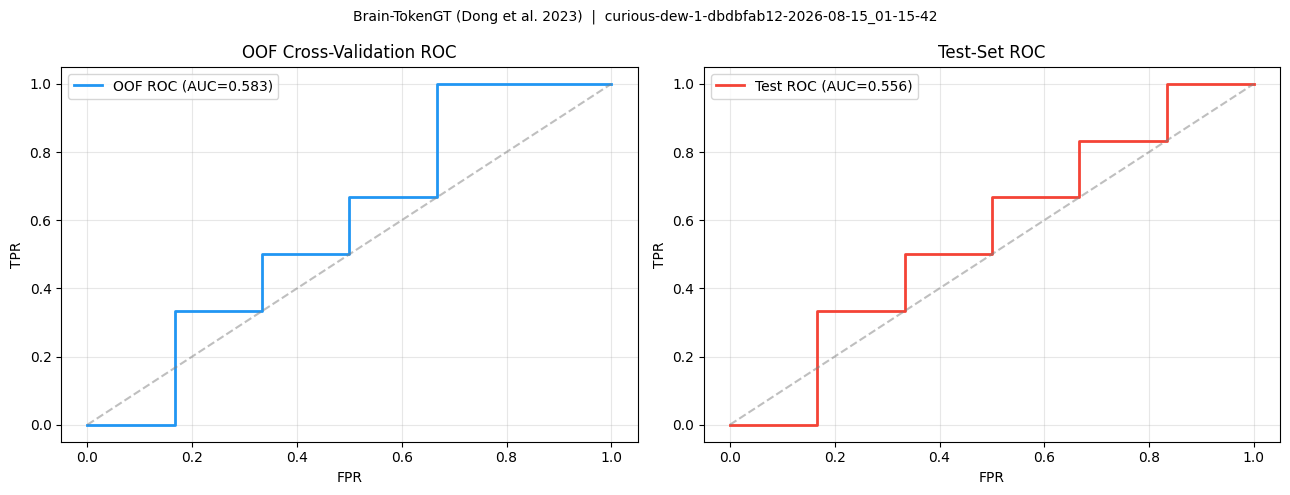

In [18]:
fig = plot_oof_test_roc(
    OOF_TARGETS, OOF_PROBS, TEST_METRICS['targets'], TEST_METRICS['probs'],
    title=f'Brain-TokenGT (Dong et al. 2023)  |  {RUN_NAME}',
)
plt.show()

## Early-Detection Curve: AUC vs. Number of Visits Used

Same shared `early_detection_table` the CLASSIFIER models use: for each N it
restricts every test subject with `T >= N` visits to their first N and re-scores.

In [19]:
ED_ROWS = early_detection_table(
    TEST_BUNDLE, eval_split, truncate_to_n_visits,
    BEST_MODEL_STATE, ACTIVE_THRESHOLD, device=device,
)


Visits    N      AUC     Sens     Spec
----------------------------------------


     1   12   0.5833    0.833    0.500


     2   12   0.6111    0.833    0.333
     3    4   0.3333    1.000    0.000


## Conversion Probability Trajectories

Trajectory data: 12 subjects


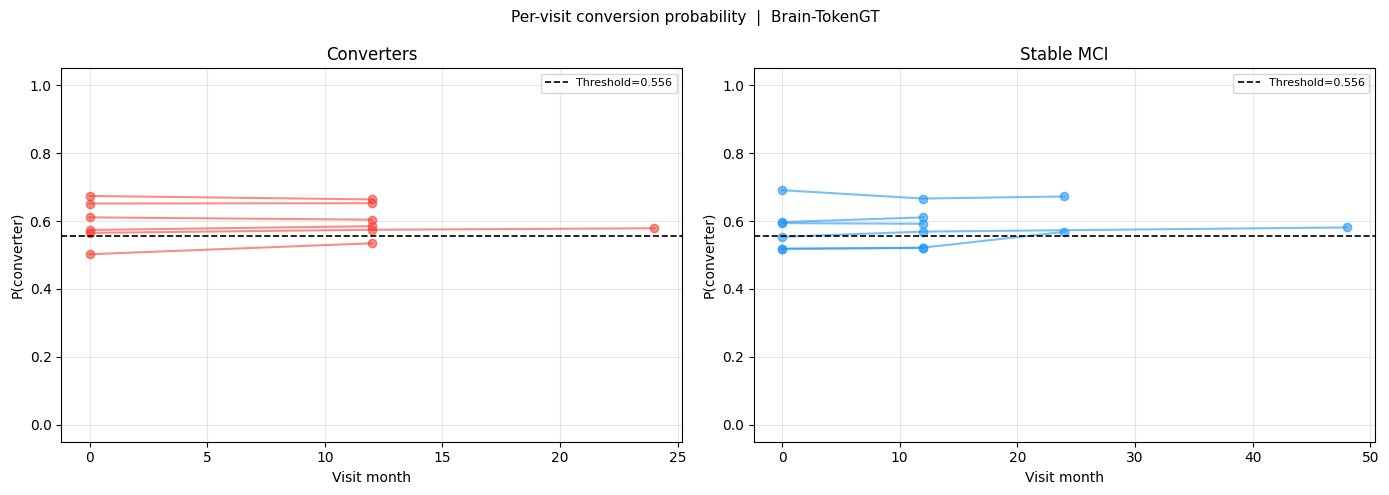

In [20]:
TRAJ_DF = trajectory_frame(TEST_BUNDLE, per_visit_probs, BEST_MODEL_STATE, device=device)
if len(TRAJ_DF):
    print(f"Trajectory data: {TRAJ_DF['pid'].nunique()} subjects")
    fig = plot_conversion_trajectories(
        TRAJ_DF, ACTIVE_THRESHOLD,
        title='Per-visit conversion probability  |  Brain-TokenGT',
    )
    plt.show()
else:
    print('No test subject has >= 2 visits — nothing to plot.')

## Provenance note for the write-up

This run used the authors' released model implementation, ported only for
`(M, T)` generalisation and device placement. The equivalence of that port to
upstream at the authors' published configuration is asserted by:

```
pytest BRAINTOKENGT/tests/test_upstream_equivalence.py -q
```

Read `model_config.upstream_faithful` in `run_summary.json` to see whether this
particular run reproduces the released code exactly (`true`) or enables one or more
repairs (`false`).

In [21]:
print('Fidelity flags for this run:')
for k in ('edge_weight_mode', 'readout', 'force_single_head', 'train_give',
          'upstream_faithful', 'min_visits', 'max_visits'):
    print(f'  {k:22s} = {MODEL_CONFIG[k]}')
try:
    tracking.finish_run(WANDB_RUN)
except Exception:
    pass

Fidelity flags for this run:
  edge_weight_mode       = binary
  readout                = mean
  force_single_head      = True
  train_give             = False
  upstream_faithful      = True
  min_visits             = 2
  max_visits             = 3
